# Machine Learning models

In this notebook we focus on training machine learning models to separate groups with CD vs nonIBD and UC vs nonIBD based only on the microbiome data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# Load data
meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)
meta = meta.loc[genera_clr.index]

print("Metadata shape:", meta.shape)
print("Genera CLR shape:", genera_clr.shape)
print("\nDiagnosis counts:")
print(meta["Study.Group"].value_counts())

Metadata shape: (105, 23)
Genera CLR shape: (105, 2761)

Diagnosis counts:
Study.Group
CD        49
UC        30
nonIBD    26
Name: count, dtype: int64


## Prepare two binary datasets

For the following of the analysis we create two completely separate datasets. Each has the same genera columns but different rows (subjects). The labels are binary: 1 for the IBD group and 0 for the nonIBD. We note again that the two classifiaction problems are independent.

In [3]:
def make_binary_dataset(meta, genera, group_a, group_b):
    """
    Filters metadata and genera to only include two groups.
    Returns X (features) and y (binary labels).
    """
    mask = meta["Study.Group"].isin([group_a, group_b])
    meta_sub = meta[mask]
    X = genera.loc[meta_sub.index]
    y = (meta_sub["Study.Group"] == group_a).astype(int)
    # 1 = group_a, 0 = group_b
    print(f"\n{group_a} vs {group_b}")
    print(f"  {group_a}: {(y==1).sum()} samples")
    print(f"  {group_b}: {(y==0).sum()} samples")
    print(f"  Total: {len(y)} samples")
    return X, y

X_uc, y_uc = make_binary_dataset(meta, genera_clr, "UC", "nonIBD")
X_cd, y_cd = make_binary_dataset(meta, genera_clr, "CD", "nonIBD")


UC vs nonIBD
  UC: 30 samples
  nonIBD: 26 samples
  Total: 56 samples

CD vs nonIBD
  CD: 49 samples
  nonIBD: 26 samples
  Total: 75 samples


## Feature Selection with Kruskal-Wallis filter

We keep the top 100 genera.

In [4]:
def kruskal_feature_selection(X, y, top_k):
    """
    Runs Kruskal-Wallis test for each genus between the two groups.
    Returns the names of the top_k most significant genera.
    """
    group0 = X[y == 0]
    group1 = X[y == 1]
    
    p_values = []
    for col in X.columns:
        stat, p = kruskal(group0[col].values, group1[col].values)
        p_values.append(p)
    
    p_series = pd.Series(p_values, index=X.columns)
    top_features = p_series.nsmallest(top_k).index.tolist()
    return top_features, p_series

# Run for both tasks, keep top 100 genera
print("=== UC vs nonIBD ===")
uc_features, uc_pvals = kruskal_feature_selection(X_uc, y_uc, top_k=100)
print(f"Top 100 genera selected by Kruskal-Wallis")
print(f"Best p-value: {uc_pvals.min():.4f}")

print("\n=== CD vs nonIBD ===")
cd_features, cd_pvals = kruskal_feature_selection(X_cd, y_cd, top_k=100)
print(f"Top 100 genera selected by Kruskal-Wallis")
print(f"Best p-value: {cd_pvals.min():.4f}")

=== UC vs nonIBD ===
Top 100 genera selected by Kruskal-Wallis
Best p-value: 0.0013

=== CD vs nonIBD ===
Top 100 genera selected by Kruskal-Wallis
Best p-value: 0.0007


## Feature Selection with PCA

We retain the 80% of the variance.

In [5]:
def pca_feature_selection(X, variance_threshold=0.80):
    """
    Applies PCA and keeps enough components to explain
    the target variance threshold.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=min(X.shape[0]-1, X.shape[1]))
    pca.fit(X_scaled)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= variance_threshold) + 1
    
    print(f"Components to explain {variance_threshold*100:.0f}% variance: {n_components}")
    print(f"Variance explained by first 10 PCs: {cumvar[9]*100:.1f}%")
    
    # Refit with correct number of components
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)
    
    return X_pca, pca_final, scaler, n_components

print("=== UC vs nonIBD ===")
X_uc_pca, pca_uc, scaler_uc, n_uc = pca_feature_selection(X_uc)

print("\n=== CD vs nonIBD ===")
X_cd_pca, pca_cd, scaler_cd, n_cd = pca_feature_selection(X_cd)

=== UC vs nonIBD ===
Components to explain 80% variance: 32
Variance explained by first 10 PCs: 47.6%

=== CD vs nonIBD ===
Components to explain 80% variance: 41
Variance explained by first 10 PCs: 44.4%


# Comments on the features

Both binary classification tasks seem to have modest biological signal. We do not expect a perfect classification, but a solid one that could improve adding more parameters to the process (like age, gender or BMI).

## Next Step: Cross Validation loop

We need to define all the models that we are going to use with their hyperparameters. Then we will pick the best of every combination.

We note that for the 2 loops:

* The outer loop evaluates performance and in each loop we test a different set of the subjects.
* The inner loop tunes the hyperparameters on the training data only.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"C": [0.01, 0.1, 1, 10, 100]}
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [3, 5, None]}
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
        {"n_estimators": [100, 200], "max_depth": [3, 5],
         "learning_rate": [0.01, 0.1]}
    )
}

print("Models defined:")
for name, (model, params) in models.items():
    n_combinations = 1
    for v in params.values():
        n_combinations *= len(v)
    print(f"  {name}: {n_combinations} hyperparameter combinations")

Models defined:
  Logistic Regression: 5 hyperparameter combinations
  SVM: 6 hyperparameter combinations
  Random Forest: 6 hyperparameter combinations
  XGBoost: 8 hyperparameter combinations


# Cross validation with Kruskas-Wallis feature selection

In [7]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score)

def nested_cv(X, y, models, task_name, top_k=100, n_outer=5, n_inner=5):
    """
    Performs nested cross-validation with Kruskal-Wallis feature selection.
    
    Outer loop: evaluates model performance
    Inner loop: tunes hyperparameters
    Feature selection: happens inside outer loop to prevent data leakage
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_name}")
    print(f"Samples: {len(y)}, Positives: {y.sum()}, Negatives: {(y==0).sum()}")
    print(f"{'='*60}")
    
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)
    
    # Store results per model
    all_results = {name: {
        "auc": [], "accuracy": [], "f1": [],
        "precision": [], "recall": [],
        "y_true": [], "y_prob": []
    } for name in models}
    
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Outer Fold {fold+1}/{n_outer} ---")
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # --- Feature selection on training data only ---
        # Kruskal-Wallis on X_train only (no leakage)
        p_values = []
        for col in X_train.columns:
            group0 = X_train[col][y_train == 0].values
            group1 = X_train[col][y_train == 1].values
            stat, p = kruskal(group0, group1)
            p_values.append(p)
        
        p_series = pd.Series(p_values, index=X_train.columns)
        top_features = p_series.nsmallest(top_k).index.tolist()
        
        X_train_sel = X_train[top_features]
        X_test_sel = X_test[top_features]
        
        # --- Inner loop: hyperparameter tuning ---
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=42)
        
        for name, (model, param_grid) in models.items():
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=-1
            )
            grid_search.fit(X_train_sel, y_train)
            best_model = grid_search.best_estimator_
            
            # --- Evaluate on outer test fold ---
            y_prob = best_model.predict_proba(X_test_sel)[:, 1]
            y_pred = best_model.predict(X_test_sel)
            
            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            
            all_results[name]["auc"].append(auc)
            all_results[name]["accuracy"].append(acc)
            all_results[name]["f1"].append(f1)
            all_results[name]["precision"].append(prec)
            all_results[name]["recall"].append(rec)
            all_results[name]["y_true"].extend(y_test.tolist())
            all_results[name]["y_prob"].extend(y_prob.tolist())
            
            print(f"  {name:22s} AUC={auc:.3f}  "
                  f"Best params: {grid_search.best_params_}")
    
    return all_results


# Run for both tasks
results_uc_kw = nested_cv(X_uc, y_uc, models, task_name="UC vs nonIBD")
results_cd_kw = nested_cv(X_cd, y_cd, models, task_name="CD vs nonIBD")


Task: UC vs nonIBD
Samples: 56, Positives: 30, Negatives: 26

--- Outer Fold 1/5 ---
  Logistic Regression    AUC=0.444  Best params: {'C': 100}
  SVM                    AUC=0.444  Best params: {'C': 10, 'kernel': 'rbf'}
  Random Forest          AUC=0.556  Best params: {'max_depth': 5, 'n_estimators': 200}
  XGBoost                AUC=0.556  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 2/5 ---
  Logistic Regression    AUC=0.533  Best params: {'C': 100}
  SVM                    AUC=0.633  Best params: {'C': 1, 'kernel': 'rbf'}
  Random Forest          AUC=0.683  Best params: {'max_depth': 5, 'n_estimators': 100}
  XGBoost                AUC=0.533  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 3/5 ---
  Logistic Regression    AUC=0.700  Best params: {'C': 1}
  SVM                    AUC=0.567  Best params: {'C': 1, 'kernel': 'rbf'}
  Random Forest          AUC=0.267  Best params: {'max_depth': 3, 'n_e

## Results

In the following cell we summarize the results.

The results are reported as the mean ± std across the outer loop runs. Our primary metric is AUC (area under curve) for the ROC plot. For the results:

* For the UC vs nonIBD classification all models are around chance level (0.5) with AUC 0.43-0.55. So we can see that UC cannot be reliably distinguished from nonIBD
using fecal microbiome data alone in this cohort.

* For the CD vs nonIBD classification models range from AUC 0.58–0.67, clearly above chance. Logistic Regression leads at 0.665 ± 0.124, which is respectable
for microbiome-only classification with 105 subjects. Notably, simpler models (LR, SVM) outperform complex ones (Random Forest, XGBoost) — a common finding in small datasets where complex models overfit.

In [8]:
def summarize_results(all_results, task_name):
    """
    Summarizes nested CV results into a clean DataFrame
    showing mean ± std across outer folds for each metric.
    """
    rows = []
    for name, metrics in all_results.items():
        rows.append({
            "Model": name,
            "AUC": f"{np.mean(metrics['auc']):.3f} ± {np.std(metrics['auc']):.3f}",
            "Accuracy": f"{np.mean(metrics['accuracy']):.3f} ± {np.std(metrics['accuracy']):.3f}",
            "F1": f"{np.mean(metrics['f1']):.3f} ± {np.std(metrics['f1']):.3f}",
            "Precision": f"{np.mean(metrics['precision']):.3f} ± {np.std(metrics['precision']):.3f}",
            "Recall": f"{np.mean(metrics['recall']):.3f} ± {np.std(metrics['recall']):.3f}",
            "AUC_mean": np.mean(metrics['auc'])  # for sorting
        })
    
    df = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False)
    df = df.drop(columns="AUC_mean").reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print(f"Results: {task_name}")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    return df

df_uc_kw = summarize_results(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis features)")
df_cd_kw = summarize_results(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis features)")

# Save to results/tables
df_uc_kw.to_csv("../results/tables/ml_results_kw_uc.csv", index=False)
df_cd_kw.to_csv("../results/tables/ml_results_kw_cd.csv", index=False)
print("\nSaved results to results/tables/")


Results: UC vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
                SVM 0.549 ± 0.095 0.574 ± 0.104 0.644 ± 0.103 0.591 ± 0.120 0.733 ± 0.170
Logistic Regression 0.542 ± 0.100 0.536 ± 0.060 0.604 ± 0.063 0.559 ± 0.061 0.667 ± 0.105
            XGBoost 0.491 ± 0.117 0.533 ± 0.150 0.577 ± 0.132 0.575 ± 0.145 0.600 ± 0.170
      Random Forest 0.434 ± 0.164 0.392 ± 0.134 0.432 ± 0.127 0.432 ± 0.123 0.433 ± 0.133

Results: CD vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
Logistic Regression 0.665 ± 0.124 0.653 ± 0.078 0.743 ± 0.063 0.724 ± 0.092 0.773 ± 0.083
                SVM 0.637 ± 0.139 0.627 ± 0.116 0.740 ± 0.105 0.663 ± 0.071 0.853 ± 0.181
      Random Forest 0.626 ± 0.128 0.600 ± 0.073 0.718 ± 0.043 0.675 ± 0.080 0.776 ± 0.039
            XGBoost 0.581 ± 0.194 0.640 ± 0.080 0.740 ± 0.078 0.707 ± 0.083 0.820 ± 0.183

S

## ROC plots

The ROC (Receiver Operating Characteristic) curve plots True Positive Rate (sensitivity) against False Positive Rate (1-specificity) at every possible classification threshold. A perfect classifier would reach the top-left corner. The diagonal dashed line represents a random classifier (AUC = 0.500).

### Observations

- **UC vs nonIBD:** All curves hug the diagonal — no model learns a reliable pattern. Random Forest (0.435) falls below random, indicating it overfits to noise in this weak-signal task.
- **CD vs nonIBD:** All curves are consistently above the diagonal. Logistic Regression shows the best separation, confirming CD produces a stronger and more learnable microbiome signature than UC.
- The staircase shape of the curves is normal with small datasets — each step represents one subject crossing the decision threshold.

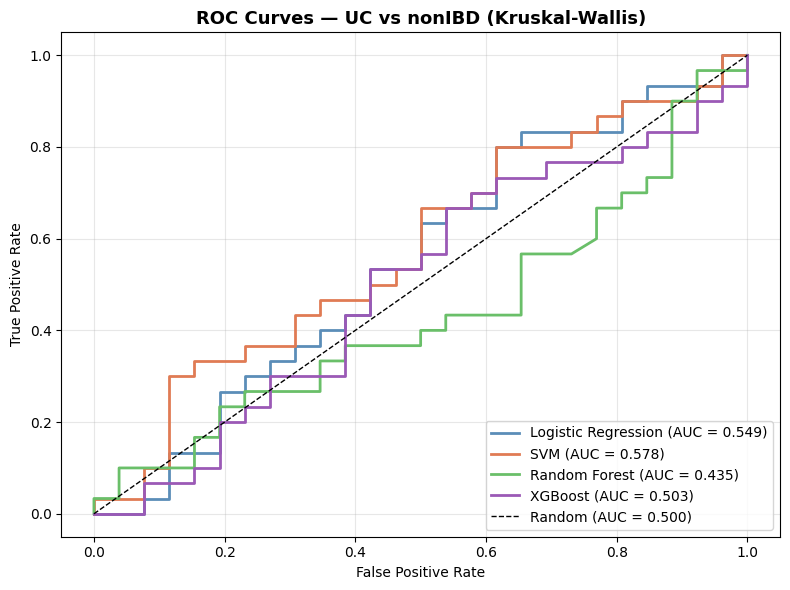

Saved: ../results/figures/13_roc_kw_uc.png


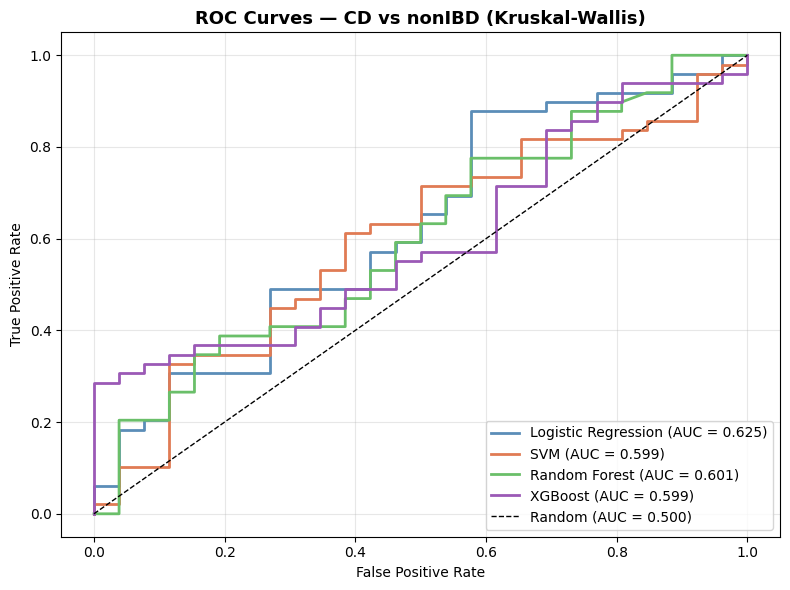

Saved: ../results/figures/14_roc_kw_cd.png


In [9]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(all_results, task_name, save_path):
    """
    Plots ROC curves for all models on the same figure.
    Uses aggregated predictions from all outer folds.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = ["#5b8db8", "#e07b54", "#6abf69", "#9b59b6"]
    
    for (name, metrics), color in zip(all_results.items(), colors):
        y_true = np.array(metrics["y_true"])
        y_prob = np.array(metrics["y_prob"])
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC = {roc_auc:.3f})")
    
    # Random classifier baseline
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
    
    ax.set_title(f"ROC Curves — {task_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_roc_curves(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis)",
                "../results/figures/13_roc_kw_uc.png")

plot_roc_curves(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis)",
                "../results/figures/14_roc_kw_cd.png")

## Confusion Matrix plots

Why do we need them?
Clinically, **false negatives are the most dangerous** — a missed IBD patient does not receive treatment!

For the results we have the following comments

The best model predicts UC for the majority of subjects regardless of true label. It correctly identifies 21/30 UC patients (70% recall) but misclassifies 16/26 nonIBD patients as UC (high false positive rate). This pattern confirms the model is not genuinely learning UC-specific microbiome ffeatures — it is biased toward predicting the majority class.

For CD vs nonIBD he model correctly identifies 38/49 CD patients (78% recall) and 11/26 nonIBD patients (42% specificity). The false positive rate is still high — 15 nonIBD subjects are misclassified as CD — but the true positive detection is meaningful and above chance. The asymmetry between CD recall (78%) and nonIBD specificity (42%) suggests the model has learned real CD-associated microbiome patterns but lacks enough nonIBD contrast samples to sharpen the boundary.

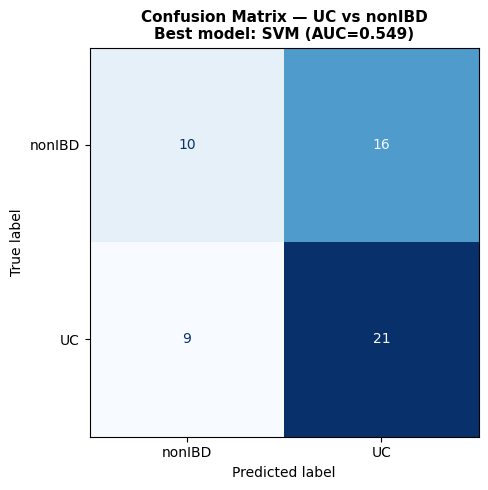

Best model: SVM
Saved: ../results/figures/15_confusion_kw_uc.png


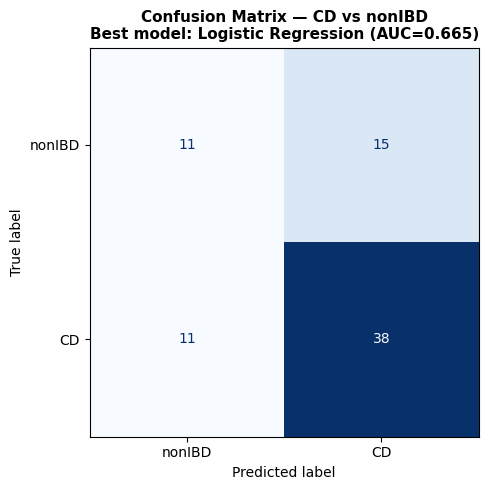

Best model: Logistic Regression
Saved: ../results/figures/16_confusion_kw_cd.png


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(all_results, task_name, class_names, save_path):
    """
    Plots confusion matrix for the best model (highest AUC).
    Uses aggregated predictions from all outer folds.
    """
    # Find best model by mean AUC
    best_name = max(all_results, key=lambda n: np.mean(all_results[n]["auc"]))
    best = all_results[best_name]
    
    y_true = np.array(best["y_true"])
    y_prob = np.array(best["y_prob"])
    y_pred = (y_prob >= 0.5).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    
    ax.set_title(f"Confusion Matrix — {task_name}\n"
                 f"Best model: {best_name} "
                 f"(AUC={np.mean(best['auc']):.3f})",
                 fontsize=11, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Best model: {best_name}")
    print(f"Saved: {save_path}")

plot_confusion_matrix(results_uc_kw, "UC vs nonIBD",
                      class_names=["nonIBD", "UC"],
                      save_path="../results/figures/15_confusion_kw_uc.png")

plot_confusion_matrix(results_cd_kw, "CD vs nonIBD",
                      class_names=["nonIBD", "CD"],
                      save_path="../results/figures/16_confusion_kw_cd.png")

## Cross validation with PCA feature selection

Now we perform the same analysis with the features selected with PCA.

In [11]:
def nested_cv_pca(X, y, models, task_name, variance_threshold=0.80, n_outer=5, n_inner=5):
    """
    Performs nested cross-validation with PCA feature reduction.
    Scaler and PCA are fit inside the outer loop on training data only.
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_name} (PCA features)")
    print(f"Samples: {len(y)}, Positives: {y.sum()}, Negatives: {(y==0).sum()}")
    print(f"{'='*60}")

    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)

    all_results = {name: {
        "auc": [], "accuracy": [], "f1": [],
        "precision": [], "recall": [],
        "y_true": [], "y_prob": []
    } for name in models}

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Outer Fold {fold+1}/{n_outer} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # --- PCA on training data only ---
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Find number of components for variance threshold
        pca_full = PCA(n_components=min(X_train.shape[0]-1, X_train.shape[1]))
        pca_full.fit(X_train_scaled)
        cumvar = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = np.argmax(cumvar >= variance_threshold) + 1

        # Apply PCA with correct number of components
        pca = PCA(n_components=n_components, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)

        print(f"  PCA components used: {n_components}")

        # --- Inner loop: hyperparameter tuning ---
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=42)

        for name, (model, param_grid) in models.items():
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=-1
            )
            grid_search.fit(X_train_pca, y_train)
            best_model = grid_search.best_estimator_

            y_prob = best_model.predict_proba(X_test_pca)[:, 1]
            y_pred = best_model.predict(X_test_pca)

            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)

            all_results[name]["auc"].append(auc)
            all_results[name]["accuracy"].append(acc)
            all_results[name]["f1"].append(f1)
            all_results[name]["precision"].append(prec)
            all_results[name]["recall"].append(rec)
            all_results[name]["y_true"].extend(y_test.tolist())
            all_results[name]["y_prob"].extend(y_prob.tolist())

            print(f"  {name:22s} AUC={auc:.3f}  "
                  f"Components={n_components}  "
                  f"Best params: {grid_search.best_params_}")

    return all_results


# Run for both tasks
results_uc_pca = nested_cv_pca(X_uc, y_uc, models, task_name="UC vs nonIBD")
results_cd_pca = nested_cv_pca(X_cd, y_cd, models, task_name="CD vs nonIBD")


Task: UC vs nonIBD (PCA features)
Samples: 56, Positives: 30, Negatives: 26

--- Outer Fold 1/5 ---
  PCA components used: 25
  Logistic Regression    AUC=0.611  Components=25  Best params: {'C': 0.01}
  SVM                    AUC=0.611  Components=25  Best params: {'C': 1, 'kernel': 'rbf'}
  Random Forest          AUC=0.250  Components=25  Best params: {'max_depth': 3, 'n_estimators': 100}
  XGBoost                AUC=0.417  Components=25  Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 2/5 ---
  PCA components used: 27
  Logistic Regression    AUC=0.517  Components=27  Best params: {'C': 100}
  SVM                    AUC=0.333  Components=27  Best params: {'C': 0.1, 'kernel': 'linear'}
  Random Forest          AUC=0.767  Components=27  Best params: {'max_depth': 5, 'n_estimators': 100}
  XGBoost                AUC=0.550  Components=27  Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 3/5 ---
  PCA com

## Result table for PCA

In [12]:
df_uc_pca = summarize_results(results_uc_pca, "UC vs nonIBD (PCA features)")
df_cd_pca = summarize_results(results_cd_pca, "CD vs nonIBD (PCA features)")

df_uc_pca.to_csv("../results/tables/ml_results_pca_uc.csv", index=False)
df_cd_pca.to_csv("../results/tables/ml_results_pca_cd.csv", index=False)
print("\nSaved PCA results to results/tables/")


Results: UC vs nonIBD (PCA features)
              Model           AUC      Accuracy            F1     Precision        Recall
Logistic Regression 0.506 ± 0.067 0.409 ± 0.100 0.443 ± 0.237 0.383 ± 0.197 0.533 ± 0.306
            XGBoost 0.487 ± 0.216 0.517 ± 0.139 0.581 ± 0.141 0.584 ± 0.216 0.667 ± 0.279
                SVM 0.476 ± 0.098 0.517 ± 0.097 0.517 ± 0.270 0.445 ± 0.226 0.633 ± 0.356
      Random Forest 0.470 ± 0.220 0.483 ± 0.097 0.559 ± 0.088 0.536 ± 0.093 0.633 ± 0.163

Results: CD vs nonIBD (PCA features)
              Model           AUC      Accuracy            F1     Precision        Recall
      Random Forest 0.664 ± 0.148 0.667 ± 0.042 0.793 ± 0.027 0.668 ± 0.038 0.980 ± 0.040
Logistic Regression 0.657 ± 0.124 0.627 ± 0.033 0.737 ± 0.043 0.683 ± 0.044 0.818 ± 0.115
            XGBoost 0.624 ± 0.119 0.667 ± 0.140 0.773 ± 0.103 0.702 ± 0.123 0.873 ± 0.127
                SVM 0.529 ± 0.187 0.667 ± 0.073 0.761 ± 0.066 0.718 ± 0.066 0.840 ± 0.162

Saved PCA results to re

## ROC plots

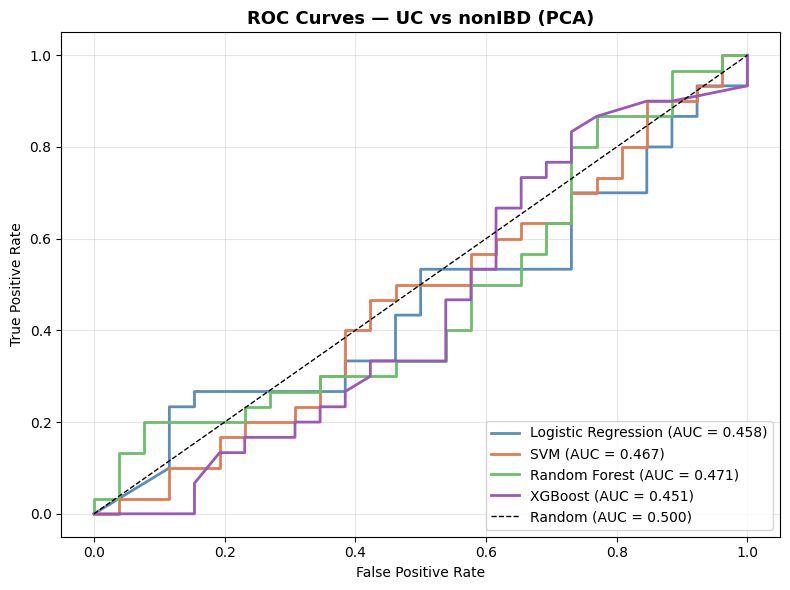

Saved: ../results/figures/17_roc_pca_uc.png


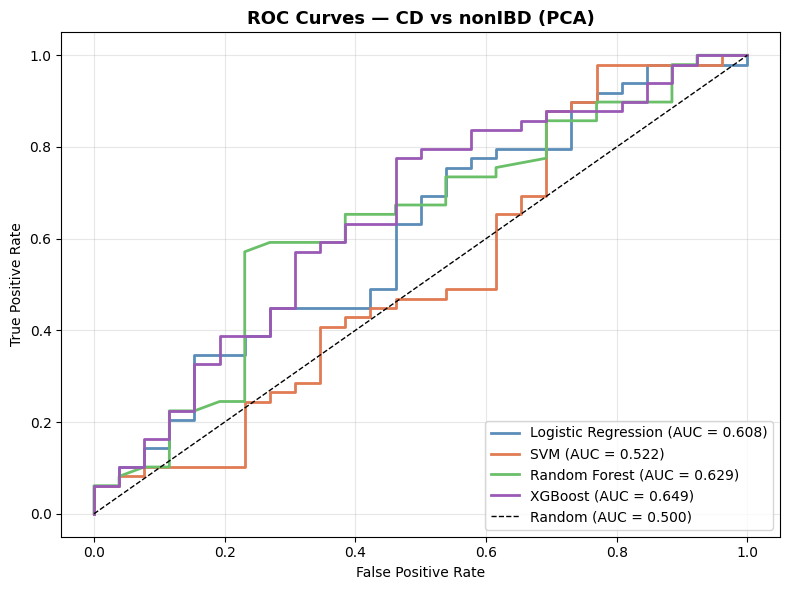

Saved: ../results/figures/18_roc_pca_cd.png


In [13]:
plot_roc_curves(results_uc_pca, "UC vs nonIBD (PCA)",
                "../results/figures/17_roc_pca_uc.png")

plot_roc_curves(results_cd_pca, "CD vs nonIBD (PCA)",
                "../results/figures/18_roc_pca_cd.png")

## Confusion Matrices

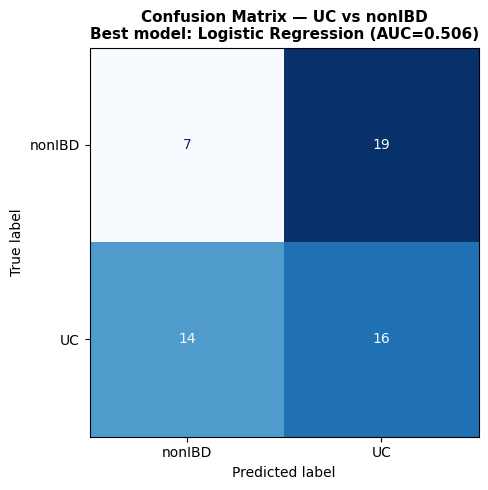

Best model: Logistic Regression
Saved: ../results/figures/19_confusion_pca_uc.png


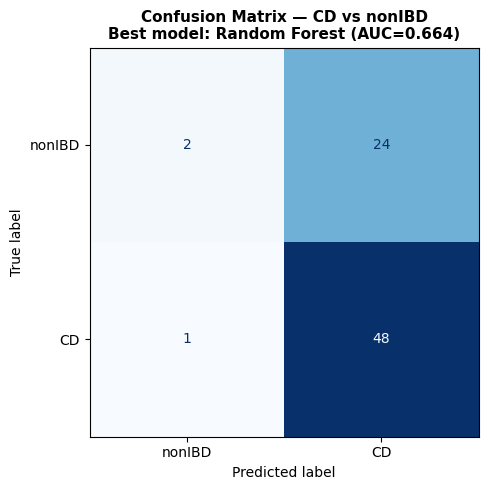

Best model: Random Forest
Saved: ../results/figures/20_confusion_pca_cd.png


In [14]:
plot_confusion_matrix(results_uc_pca, "UC vs nonIBD",
                      class_names=["nonIBD", "UC"],
                      save_path="../results/figures/19_confusion_pca_uc.png")

plot_confusion_matrix(results_cd_pca, "CD vs nonIBD",
                      class_names=["nonIBD", "CD"],
                      save_path="../results/figures/20_confusion_pca_cd.png")

In [ ]:
def comparison_table(results_kw, results_pca, task_name):
    """
    Compares KW and PCA feature selection methods
    side by side for each model.
    """
    rows = []
    for name in results_kw:
        rows.append({
            "Model": name,
            "KW AUC": f"{np.mean(results_kw[name]['auc']):.3f} ± {np.std(results_kw[name]['auc']):.3f}",
            "PCA AUC": f"{np.mean(results_pca[name]['auc']):.3f} ± {np.std(results_pca[name]['auc']):.3f}",
            "KW_mean": np.mean(results_kw[name]['auc']),
            "PCA_mean": np.mean(results_pca[name]['auc'])
        })

    df = pd.DataFrame(rows)
    df["Better"] = df.apply(
        lambda r: "KW" if r["KW_mean"] > r["PCA_mean"] else "PCA", axis=1
    )
    df = df.drop(columns=["KW_mean", "PCA_mean"])

    print(f"\n{'='*60}")
    print(f"KW vs PCA Comparison — {task_name}")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    return df

df_comp_uc = comparison_table(results_uc_kw, results_uc_pca, "UC vs nonIBD")
df_comp_cd = comparison_table(results_cd_kw, results_cd_pca, "CD vs nonIBD")

df_comp_uc.to_csv("../results/tables/comparison_uc.csv", index=False)
df_comp_cd.to_csv("../results/tables/comparison_cd.csv", index=False)
print("\nSaved comparison tables to results/tables/")


KW vs PCA Comparison — UC vs nonIBD
              Model        KW AUC       PCA AUC Better
Logistic Regression 0.542 ± 0.100 0.506 ± 0.067   KW ✓
                SVM 0.549 ± 0.095 0.476 ± 0.098   KW ✓
      Random Forest 0.434 ± 0.164 0.470 ± 0.220  PCA ✓
            XGBoost 0.491 ± 0.117 0.487 ± 0.216   KW ✓

KW vs PCA Comparison — CD vs nonIBD
              Model        KW AUC       PCA AUC Better
Logistic Regression 0.665 ± 0.124 0.657 ± 0.124   KW ✓
                SVM 0.637 ± 0.139 0.529 ± 0.187   KW ✓
      Random Forest 0.626 ± 0.128 0.664 ± 0.148  PCA ✓
            XGBoost 0.581 ± 0.194 0.624 ± 0.119  PCA ✓

Saved comparison tables to results/tables/


## Summary — Machine Learning Results

### Feature Selection Comparison
Kruskal-Wallis (KW) feature selection outperforms PCA in most settings,
particularly for UC vs nonIBD. KW selects biologically meaningful genera
directly associated with the classification task, while PCA compresses
variance without using class labels and introduces noise irrelevant to
the classification boundary.

### Task Comparison
UC vs nonIBD is not learnable from fecal microbiome alone in this cohort
(best AUC 0.549). This is consistent with known biology — UC produces a
weaker and more variable fecal microbiome signal than CD.

CD vs nonIBD shows a real learnable signal (best AUC 0.665, LR with KW).
Logistic Regression consistently outperforms more complex models, a common
finding in small biomedical datasets where simpler models generalize better.

### Best Model
Logistic Regression with Kruskal-Wallis features on CD vs nonIBD
(AUC = 0.665 ± 0.124).

### Limitations
- 105 subjects is a small cohort for microbiome ML
- High std across folds reflects dataset size limitations
- Results should be validated in larger independent cohorts
- Microbiome-only features; adding clinical variables (age, BMI) 
  may improve performance (following analysis)